<a href="https://colab.research.google.com/github/PDM-15/AML-2026/blob/master/25.08.2026/IrisDataset_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Preprocessing - iris

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Loading
drive.mount('/content/drive')

data = pd.read_csv("drive/My Drive/Dataset/Iris.csv")
dataset = data

data.info()

X = dataset.iloc[:, 1:5].values
y = dataset.iloc[:,-1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 45)

sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 7.2 KB


Decision tree

Accuracy: 94.73684210526315 %

              precision    recall  f1-score   support

           0       0.82      1.00      0.90         9
           1       1.00      1.00      1.00        14
           2       1.00      0.87      0.93        15

    accuracy                           0.95        38
   macro avg       0.94      0.96      0.94        38
weighted avg       0.96      0.95      0.95        38
 

Belongs to species type 0



[Text(0.3181818181818182, 0.9166666666666666, 'x[2] <= -0.762\ngini = 0.665\nsamples = 112\nvalue = [41, 36, 35]'),
 Text(0.22727272727272727, 0.75, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.2727272727272727, 0.8333333333333333, 'True  '),
 Text(0.4090909090909091, 0.75, 'x[3] <= 0.586\ngini = 0.497\nsamples = 76\nvalue = [41, 0, 35]'),
 Text(0.36363636363636365, 0.8333333333333333, '  False'),
 Text(0.18181818181818182, 0.5833333333333334, 'x[2] <= 0.902\ngini = 0.049\nsamples = 40\nvalue = [39, 0, 1]'),
 Text(0.09090909090909091, 0.4166666666666667, 'gini = 0.0\nsamples = 39\nvalue = [39, 0, 0]'),
 Text(0.2727272727272727, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6363636363636364, 0.5833333333333334, 'x[3] <= 0.717\ngini = 0.105\nsamples = 36\nvalue = [2, 0, 34]'),
 Text(0.45454545454545453, 0.4166666666666667, 'x[0] <= -0.071\ngini = 0.5\nsamples = 2\nvalue = [1, 0, 1]'),
 Text(0.36363636363636365, 0.25, 'gini = 0.0\nsamples = 1\nvalu

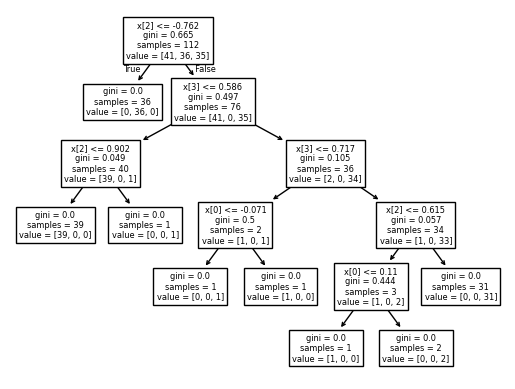

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import metrics
from sklearn import tree
#Decision tree object of DecisionTreeClassifier class
classifier = DecisionTreeClassifier(criterion = 'gini', random_state = 45) #We can give gini as criterion as well
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

"""print(y_test)
print(y_pred)
print(cm)"""

prediction = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", prediction * 100, "%\n")

print(classification_report(y_test, y_pred), "\n")

new_individual = np.array([[1.2, 2.4, 4.5, 6]])
new_individual_scaled = sc_X.transform(new_individual)
prediction = classifier.predict(new_individual_scaled)

if prediction[0] == 2:
  print("Belongs to species type 2\n")
elif prediction[0] == 1:
  print("Belongs to species type 1\n")
else:
  print("Belongs to species type 0\n")


tree.plot_tree(classifier)
